In [9]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from rss import evaluate, features, preprocess, train, utils

print('✓ Core libraries imported')

✓ Core libraries imported


In [10]:
CUSTOM_DIR = Path.cwd() # Update with actual path to project directory
# Data directory structure:
# data/
#       sleep-cassette/
#       sleep-telemetry/
DATA_DIR = CUSTOM_DIR / 'data' # Update with actual path to data
SC_DIR = DATA_DIR / 'sleep-cassette'
ST_DIR = DATA_DIR / 'sleep-telemetry'

# Checkpoint directories (modify as needed)
FEATURE_DIR_SC = CUSTOM_DIR / 'checkpoints/features/RF/sc'
FEATURE_DIR_ST = CUSTOM_DIR / 'checkpoints/features/RF/st'
MODEL_DIR = CUSTOM_DIR / 'checkpoints/model/RF'

for path in [FEATURE_DIR_SC, FEATURE_DIR_ST, MODEL_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print('SC:', SC_DIR)
print('ST:', ST_DIR)
print('Feature checkpoints:', FEATURE_DIR_SC, FEATURE_DIR_ST)
print('Model checkpoint:', MODEL_DIR)

SC: c:\Users\E1024679\Documents\RobustSleepStaging\data\sleep-cassette
ST: c:\Users\E1024679\Documents\RobustSleepStaging\data\sleep-telemetry
Feature checkpoints: c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\features\RF\sc c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\features\RF\st
Model checkpoint: c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\model\RF


In [21]:
# Build / load feature arrays from the checkpoint folders
model_path = MODEL_DIR / 'random_forest_sc.pkl'
model_path_rescaled = MODEL_DIR / 'random_forest_sc_rescaled.pkl'
scaler_path = MODEL_DIR / 'scaler_sc.pkl'

# Load SC features and labels for training and validation
X_sc, y_sc, sid_sc = utils.load_per_record_checkpoints(FEATURE_DIR_SC, load_mode='disk')
print('SC features:', X_sc.shape)

if X_sc.size > 0:
    unique_subjects = np.unique(sid_sc)
    print(unique_subjects)
    train_subjects, val_subjects = train_test_split(unique_subjects, test_size=0.2, random_state=42)
    print('Train subjects:', train_subjects)
    print('Validation subjects:', val_subjects)
    train_mask = np.isin(sid_sc, train_subjects)
    val_mask = np.isin(sid_sc, val_subjects)

    X_train_raw = X_sc[train_mask]
    y_train = y_sc[train_mask]
    X_val_raw = X_sc[val_mask]
    y_val = y_sc[val_mask]
    # Look for existing scaler checkpoint
    if scaler_path.exists():
        scaler = joblib.load(scaler_path)
        print('Loaded existing scaler checkpoint:', scaler_path)
        X_train = scaler.transform(X_train_raw)
    else:
        # Create new scaler, fit on training data, and save checkpoint
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_raw)
        joblib.dump(scaler, scaler_path, compress=3)
        print('Saved scaler checkpoint:', scaler_path)

    X_val = scaler.transform(X_val_raw)
    X_train_rescaled = X_train_raw * 1e12
    X_val_rescaled = X_val_raw * 1e12

    
    print('✓ Feature scaling complete')
    
    if model_path.exists() and model_path_rescaled.exists():
        clf = joblib.load(model_path)
        clf_rescaled = joblib.load(model_path_rescaled)
        print('Loaded existing model checkpoints:')
        print('  scaled:', model_path)
        print('  rescaled:', model_path_rescaled)

    else:
        print('No complete model checkpoints found; training new models...')

        # clf = train.random_forest(X_train, y_train, verbose=True, random_state=42)
        clf_rescaled = train.random_forest(X_train_rescaled, y_train, verbose=True, random_state=42)

        print('✓ Training complete')

        # joblib.dump(clf, model_path, compress=3)
        joblib.dump(clf_rescaled, model_path_rescaled, compress=3)

        print('Saved model checkpoints:')
        print('  scaled:', model_path)
        print('  rescaled:', model_path_rescaled)

else:
    print('No SC checkpoints found yet; run the preprocessing cell first.')

[utils] load_mode=disk — scanning checkpoint directory: c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\features\RF\sc
[utils] found 153 .npz files
[utils] scanned 50/153 files — total_epochs so far: 136394
[utils] scanned 100/153 files — total_epochs so far: 272478
[utils] scanned 150/153 files — total_epochs so far: 407016
SC features: (414961, 4744)
['SC400' 'SC401' 'SC402' 'SC403' 'SC404' 'SC405' 'SC406' 'SC407' 'SC408'
 'SC409' 'SC410' 'SC411' 'SC412' 'SC413' 'SC414' 'SC415' 'SC416' 'SC417'
 'SC418' 'SC419' 'SC420' 'SC421' 'SC422' 'SC423' 'SC424' 'SC425' 'SC426'
 'SC427' 'SC428' 'SC429' 'SC430' 'SC431' 'SC432' 'SC433' 'SC434' 'SC435'
 'SC436' 'SC437' 'SC438' 'SC440' 'SC441' 'SC442' 'SC443' 'SC444' 'SC445'
 'SC446' 'SC447' 'SC448' 'SC449' 'SC450' 'SC451' 'SC452' 'SC453' 'SC454'
 'SC455' 'SC456' 'SC457' 'SC458' 'SC459' 'SC460' 'SC461' 'SC462' 'SC463'
 'SC464' 'SC465' 'SC466' 'SC467' 'SC470' 'SC471' 'SC472' 'SC473' 'SC474'
 'SC475' 'SC476' 'SC477' 'SC480' 'SC481' 'SC482']


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  7.7min finished


[train] training complete — elapsed: 462.6s
✓ Training complete
Saved model checkpoints:
  scaled: c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\model\RF\random_forest_sc.pkl
  rescaled: c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\model\RF\random_forest_sc_rescaled.pkl


In [25]:
y_pred_val = clf.predict(X_val)
val_metrics = evaluate.get_predictions(y_val, y_pred_val)
print('=' * 40)
print('   IN-DISTRIBUTION METRICS (SC -> SC)')
print('=' * 40)
print(f'  Accuracy:      {val_metrics["accuracy"]:.3f}')
print(f'  Macro F1:      {val_metrics["macro_f1"]:.3f}')
print(f'  Cohen Kappa:   {val_metrics["kappa"]:.3f}')
print('=' * 40)

y_pred_val_rescaled = clf_rescaled.predict(X_val_rescaled)
val_metrics_rescaled = evaluate.get_predictions(y_val, y_pred_val_rescaled)
print('=' * 40)
print('   IN-DISTRIBUTION METRICS (SC -> SC) - RESCALED')
print('=' * 40)
print(f'  Accuracy:      {val_metrics_rescaled["accuracy"]:.3f}')
print(f'  Macro F1:      {val_metrics_rescaled["macro_f1"]:.3f}')
print(f'  Cohen Kappa:   {val_metrics_rescaled["kappa"]:.3f}')
print('=' * 40)

print(np.unique(y_pred_val, return_counts=True))
print(np.unique(y_pred_val_rescaled, return_counts=True))
print(np.unique(y_val, return_counts=True))

print("NaN:", np.isnan(X_train_rescaled).sum())
print("Inf:", np.isinf(X_train_rescaled).sum())

print("min:", np.nanmin(X_train_rescaled))
print("max:", np.nanmax(X_train_rescaled))
print("mean:", np.nanmean(X_train_rescaled))
print("std:", np.nanstd(X_train_rescaled))

feature_ranges = np.nanmax(X_train_rescaled, axis=0) - np.nanmin(X_train_rescaled, axis=0)

print("min feature range:", feature_ranges.min())
print("median feature range:", np.median(feature_ranges))
print("max feature range:", feature_ranges.max())

print("features with range < 1e-7:", np.sum(feature_ranges < 1e-7), "/", X_train_rescaled.shape[1])
print("features with range < 1e-8:", np.sum(feature_ranges < 1e-8), "/", X_train_rescaled.shape[1])
print("features with range < 1e-10:", np.sum(feature_ranges < 1e-10), "/", X_train_rescaled.shape[1])
print("features with range == 0:", np.sum(feature_ranges == 0), "/", X_train_rescaled.shape[1])

depths_rescaled = [est.tree_.max_depth for est in clf_rescaled.estimators_]
print("rescaled depths:", np.min(depths_rescaled), np.median(depths_rescaled), np.max(depths_rescaled))

leaves_rescaled = [est.tree_.n_leaves for est in clf_rescaled.estimators_]
print("rescaled leaves:", np.min(leaves_rescaled), np.median(leaves_rescaled), np.max(leaves_rescaled))

[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.7s finished


   IN-DISTRIBUTION METRICS (SC -> SC)
  Accuracy:      0.900
  Macro F1:      0.723
  Cohen Kappa:   0.786


[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.6s finished


   IN-DISTRIBUTION METRICS (SC -> SC) - RESCALED
  Accuracy:      0.899
  Macro F1:      0.720
  Cohen Kappa:   0.784
(array([0, 1, 2, 3, 5]), array([62875,  2175, 15873,  2183,  4285]))
(array([0, 1, 2, 3, 5]), array([62870,  2128, 15868,  2199,  4326]))
(array([0, 1, 2, 3, 5]), array([60213,  4551, 14679,  2716,  5232]))
NaN: 0
Inf: 0
min: 2.1798982e-13
max: 1.7676634e+07
mean: 2127.2456
std: 35589.824
min feature range: 0.018728567
median feature range: 28798.293
max feature range: 1.7676612e+07
features with range < 1e-7: 0 / 4744
features with range < 1e-8: 0 / 4744
features with range < 1e-10: 0 / 4744
features with range == 0: 0 / 4744
rescaled depths: 61 77.5 101
rescaled leaves: 13793 13997.5 14265


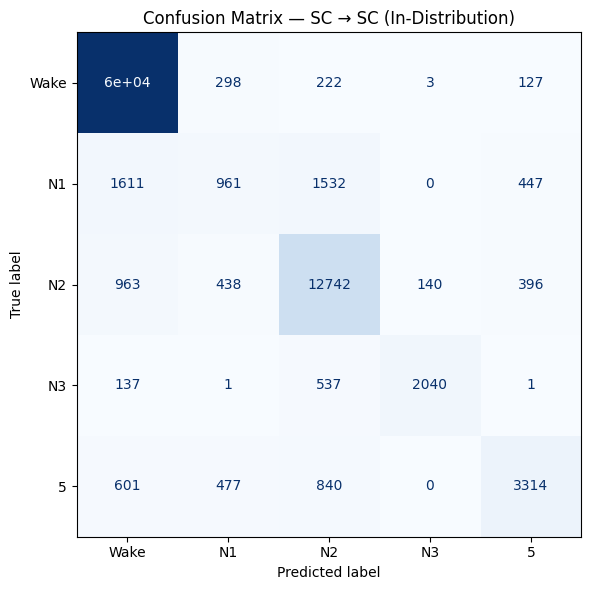

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix - SC -> SC
unique_sc = sorted(np.unique(np.concatenate([y_val, y_pred_val])))
labels_sc = [preprocess.STAGE_NAMES.get(s, str(s)) for s in unique_sc]

cm_sc = confusion_matrix(y_val, y_pred_val, labels=unique_sc)
disp_sc = ConfusionMatrixDisplay(confusion_matrix=cm_sc, display_labels=labels_sc)

fig, ax = plt.subplots(figsize=(7, 6))
disp_sc.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — SC → SC (In-Distribution)')
plt.tight_layout()
plt.show()
